# Introduction

The main goal of this notebook is to fine-tune a model and classify the economic state of the US economy using [US Macroeconomic Data](https://www.kaggle.com/datasets/sarthmirashi07/us-macroeconomic-data) dataset. For classification, we use the [TabPFN pre-trained deep learning model](https://huggingface.co/Prior-Labs/TabPFN-v2-clf). The model’s performance will be evaluated using a confusion matrix and standard evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score
  
After fine-tuning and evaluation, the classification results will be saved for later use in training a GRU model for predicting stock market prices.

To achieve this, the following methodology is applied:

1. **Dataset Preprocessing.** 

The dataset preprocessing stage focuses on validating the structure and quality of the macroeconomic data to ensure it is suitable for modelling. The following steps will be performed:

- Load the dataset into a DataFrame and inspect its structure.
- Confirm that all columns have the correct data types.
- Check for missing values, empty strings, and negative values.
- Confirm the absence of duplicated rows.
- Normalize column names.

2. **Feature Engineering and Class Balancing.**

Before performing classification, feature engineering and class balancing will be applied to prepare the dataset for modelling. The following steps will be performed:

- Create a new target variable (economic_state) that labels each observation as **Recession** or **Not Recession** based on known historical recession periods.
- Assign recession labels by matching each observation’s date to predefined recession time ranges.
- Examine the distribution of the target classes to assess whether the dataset is imbalanced.

3. **TabPFN Model Tuning and Evaluation Using the Original Dataset.**

In this section, the TabPFN model will be trained and evaluated using the original dataset to establish a baseline performance. The following steps will be performed:

- Import and configure the TabPFN model and required libraries.
- Select the computation device (CPU or GPU) based on CUDA availability.
- Split the dataset into fine-tuning and evaluation sets using a fixed date range.
- Use **macroeconomic indicators** as input features and **economic_state** as the target variable.
- Fine-tune the TabPFN model on historical data.
- Evaluate the model using standard classification metrics and a confusion matrix.
- Apply the trained model to the evaluation dataset and compare predictions with the original labels.
- Use the results to assess the impact of class imbalance.

4. **TabPFN Model Tuning and Evaluation Using SMOTE Data.**

After balancing the dataset using SMOTE, the TabPFN model will be fine-tuned and evaluated using the resampled data. The following steps will be performed:

- Apply SMOTE to generate synthetic samples for the Recession class and create a better-balanced dataset.
- Split the resampled dataset into fine-tuning and evaluation sets based on dates.
- Select **macroeconomic indicators** as input features and **economic_state** as the target variable.
- Train and fine-tune the TabPFN model using the fine-tuning dataset with SMOTE data.
- Evaluate model performance using classification metrics and a confusion matrix.
- Apply the trained model to the evaluation dataset to generate recession predictions.
- Compare the predictions on the SMOTE-balanced dataset with the predictions on the original dataset and with the original **Recession** and Not **Recession** labels.

---

# 1. Data preprocessing

In the data preprocessing section, we examine the dataset’s structure and quality. The following steps will be performed:

1. Check the data types of all columns.
2. Identify incorrect, negative, or missing values.
3. Detect and remove duplicated rows.
4. Normalize column names by converting them to lowercase.

### 1.1 Import Libraries

In [1]:
# !pip install pandas numpy

In [2]:
import pandas as pd
import numpy as np

### 1.2 Load dataset into DataFrame

In [3]:
# load dataset into Pandas DataFrame
df = pd.read_csv("./Inputs/US_macroeconomics_monthly_1981_2022.csv")
df.head()

,date,CPI,Mortgage_rate,Unemp_rate,NASDAQ,disposable_income,Personal_consumption_expenditure,personal_savings
0,1980-11-01,85.6,14.2050,7.5,200.685556,4976.5,1826.8,11.6
1,1980-12-01,86.4,14.7900,7.2,198.398636,4999.8,1851.7,11.4
2,1981-01-01,87.2,14.9040,7.5,198.817619,4980.4,1870.0,10.9
3,1981-02-01,88.0,15.1325,7.4,194.852105,4965.0,1884.2,10.8
4,1981-03-01,88.6,15.4000,7.4,203.593182,4979.0,1902.9,10.8


### 1.3 Validate the column's format

In [4]:
# Display infomration about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              499 non-null    object 
 1   CPI                               499 non-null    float64
 2   Mortgage_rate                     499 non-null    float64
 3   Unemp_rate                        499 non-null    float64
 4   NASDAQ                            499 non-null    float64
 5   disposable_income                 499 non-null    float64
 6   Personal_consumption_expenditure  499 non-null    float64
 7   personal_savings                  499 non-null    float64
dtypes: float64(7), object(1)
memory usage: 31.3+ KB


The **date** column is stored as an **object**, so it needs to be converted to a **datetime64** format.

All other columns are already in **float64** format, so no changes are required.

The next step is to convert the **date** column to **datetime64** format and verify the result.

In [5]:
# Convert 'data' ovbject into datetime64 format  
df["date"] = pd.to_datetime(df["date"], format = "%Y-%m-%d", errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              499 non-null    datetime64[ns]
 1   CPI                               499 non-null    float64       
 2   Mortgage_rate                     499 non-null    float64       
 3   Unemp_rate                        499 non-null    float64       
 4   NASDAQ                            499 non-null    float64       
 5   disposable_income                 499 non-null    float64       
 6   Personal_consumption_expenditure  499 non-null    float64       
 7   personal_savings                  499 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 31.3 KB


### 1.4 Check for incorrect values or duplicate rows

In [6]:
df.isna().sum()

date                                0
CPI                                 0
Mortgage_rate                       0
Unemp_rate                          0
NASDAQ                              0
disposable_income                   0
Personal_consumption_expenditure    0
personal_savings                    0
dtype: int64

All columns contain values.

The next step is to check for rows that contain empty strings.

In [7]:
(df == "").sum()

date                                0
CPI                                 0
Mortgage_rate                       0
Unemp_rate                          0
NASDAQ                              0
disposable_income                   0
Personal_consumption_expenditure    0
personal_savings                    0
dtype: int64

We can see that there are no rows with empty strings.

Next, we check for negative values.

In [8]:
(df[["CPI", "Mortgage_rate", "Unemp_rate", "NASDAQ", "disposable_income", "Personal_consumption_expenditure", "personal_savings"]] < 0).sum()

CPI                                 0
Mortgage_rate                       0
Unemp_rate                          0
NASDAQ                              0
disposable_income                   0
Personal_consumption_expenditure    0
personal_savings                    0
dtype: int64

No negative values are present in any of the columns.

The next step is to check for duplicated rows in the DataFrame.

In [9]:
df.duplicated().sum()

np.int64(0)

No duplicated rows are found in the DataFrame.

The final step in this section is to normalize the column names by converting them to lowercase.

In [10]:
# Convert all column names to lower case
df.columns = df.columns.str.lower()
df.head()

,date,cpi,mortgage_rate,unemp_rate,nasdaq,disposable_income,personal_consumption_expenditure,personal_savings
0,1980-11-01,85.6,14.2050,7.5,200.685556,4976.5,1826.8,11.6
1,1980-12-01,86.4,14.7900,7.2,198.398636,4999.8,1851.7,11.4
2,1981-01-01,87.2,14.9040,7.5,198.817619,4980.4,1870.0,10.9
3,1981-02-01,88.0,15.1325,7.4,194.852105,4965.0,1884.2,10.8
4,1981-03-01,88.6,15.4000,7.4,203.593182,4979.0,1902.9,10.8


The dataset was validated by checking the data types of all columns. The **date** column was converted from object to datetime format, while all numeric columns were already in the correct format.

Data quality was then checked by looking for empty values, empty strings, negative values, and duplicated rows. No issues were found.

This confirms that the dataset is clean and ready for the next steps, including feature engineering, class balance analysis, and classification.

---

# 2. Feature Engineering and Class Balancing

Before performing classification, we apply feature engineering by creating a new target variable(economic_state) that labels each observation as **Recession** or **Not Recession** based on historical data. We then examine the class distribution to determine whether the dataset is imbalanced.

Even if class imbalance is present, we first fine-tune the TabPFN model using the original imbalanced dataset to evaluate its baseline performance. Next, we will apply SMOTE to generate synthetic samples and balance the class distribution. Finally, we will fine-tune the TabPFN model again using the more balanced dataset and compare the results.

### 2.1 Import Libraries

In [11]:
# !pip install matplotlib scikit-learn imbalanced-learn

In [12]:
import matplotlib.pyplot as plt
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

### 2.2 Add "economic state" column to the dataframe and populate it

In this step, known recession periods are defined using historical dates. Each row in the dataset is then checked against these periods to determine whether it falls within a recession.

A new column, economic_state, is created to label each date as either **Recession** or **Not Recession** based on the corresponding month.

In [13]:
# Periods when US economy was in Recession
recessions = [
    ("1980-01", "1980-07"),
    ("1981-07", "1982-11"),
    ("1990-07", "1991-03"),
    ("2001-03", "2001-11"),
    ("2007-12", "2009-06"),
    ("2020-02", "2020-04"),
]

# Set to hold unique peridos
recession_set = set()

# Populate recession set
for start, end in recessions:
    recession_set.update(pd.period_range(start=start, end=end, freq="M"))

# Function to populate economic_state column based on the the period of the entry
def classifyPeriod(period):
    # Check if period of the entry is part of the recession set. 
    # If yes then set economic_state to 'Recession' 
    # else set economic_state to 'Not Recession
    if period in recession_set:
        return "Recession"
    else:
        return "Not Recession"

# Create temp 'period' comlumn and convert dates to monthly periods 
df["period"] = df["date"].dt.to_period("M")

# Assign economic_state value based on the entry period
df["economic_state"] = df["period"].apply(classifyPeriod)

# Remove the temp period column
df = df.drop(["period"], axis=1)

df.head()

,date,cpi,mortgage_rate,unemp_rate,nasdaq,disposable_income,personal_consumption_expenditure,personal_savings,economic_state
0,1980-11-01,85.6,14.2050,7.5,200.685556,4976.5,1826.8,11.6,Not Recession
1,1980-12-01,86.4,14.7900,7.2,198.398636,4999.8,1851.7,11.4,Not Recession
2,1981-01-01,87.2,14.9040,7.5,198.817619,4980.4,1870.0,10.9,Not Recession
3,1981-02-01,88.0,15.1325,7.4,194.852105,4965.0,1884.2,10.8,Not Recession
4,1981-03-01,88.6,15.4000,7.4,203.593182,4979.0,1902.9,10.8,Not Recession


This step counts how many records belong to each economic state class.

In [14]:
print(df['economic_state'].value_counts())

economic_state
Not Recession    442
Recession         57
Name: count, dtype: int64


The dataset contains significantly more **Not Recession** periods than **Recession** periods. Specifically, there are **442** non-recession records and **57** recession records, indicating a clear class imbalance in the data.

Despite this, the TabPFN model will first be trained on the original imbalanced dataset to establish a baseline performance. Then, SMOTE will be applied to balance the classes, and the TabPFN model will be retrained on the balanced dataset to compare the results.

---

# 3. TabPFN Model Tuning and Evaluation using only original data

### 3.1 Import Model from Hugging Face and Set Up Access Token

In [15]:
# !pip install torch tabpfn scikit-learn huggingface_hub

In [16]:
import torch

from tabpfn import TabPFNClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from huggingface_hub import login

# Please paste your hugging face token here
login(token="-")

/home/user/anaconda3/envs/GRU/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.2 Verify CUDA Availability

This step checks if CUDA is available for PyTorch.

If available, the device is set to **cuda** for GPU computation; otherwise, it defaults to **cpu**. The selected device is then displayed.

In [17]:
device = "cpu"

# Check if CUDA is available.
# If true then set device to CUDA
# Else keep device to be CPU and print message
if (torch.cuda.is_available()):
    device = "cuda"
    print(f"Device is: {device}")
else:
    print(f"Cuda is not available. Device is: {device}")

Device is: cuda


### 3.3 Create Fine-Tune and Evaluation Datasets

In this step, the dataset is split into fine-tuning and evaluation sets based on dates.
- **df_fine_tuning_original** contains data **before** the evaluation period.
- **df_evaluation_with_saved_labels** and **df_evaluation_original** contain data **within** the evaluation period.
- The **economic_state** column in the evaluation set is cleared to prepare it for predictions.


In [18]:
# Date from where the evaluation dataset should start
df_evaluation_start_date = pd.Timestamp("2018-12-31")
# Date where the evaluation dataset should end
df_evaluation_end_date = pd.Timestamp("2022-05-01")

# Create fine-tuning dataset from the beginning of the original dataset up until the beginning of the evaluation dataset
df_fine_tuning_original = df[~df["date"].between(df_evaluation_start_date, df_evaluation_end_date)]

# Create evaluation Dataset with saved economic_state values.
# Going to be used at the end of this section to compare predicted values on the evaluation dataset vs actual values.
df_evaluation_with_saved_labels = df[df["date"].between(df_evaluation_start_date, df_evaluation_end_date)]

# Create evaluation Dataset that is going to be used to create predictions
df_evaluation_original = df[df["date"].between(df_evaluation_start_date, df_evaluation_end_date)]

# Remove values from economic_state column.
df_evaluation_original["economic_state"] = ""

/tmp/ipykernel_134686/1204071181.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evaluation_original["economic_state"] = ""


### 3.4 Prepare Features and Target, and Split into Train and Test Sets

Here, we select the relevant macroeconomic indicators as **features** and use **economic_state** as the **target**.

The data is then split into training and testing sets.

In [19]:
# List of features that are going to be for TabPFN fine-nuning
features_original = df_fine_tuning_original[[
    "cpi",
    "mortgage_rate",
    "unemp_rate",
    "nasdaq",
    "disposable_income",
    "personal_consumption_expenditure",
    "personal_savings"
]]

# Target for TabPFN fine-tuning
target_original = df_fine_tuning_original["economic_state"]

In [20]:
# Split features and target using 80/20 ratio  
features_train_original, features_test_original, target_train_original, target_test_original = train_test_split(
    features_original,
    target_original,
    test_size=0.2, 
    random_state = 42, 
    stratify = target_original
)

### 3.4 Build the TabPFN Model, and Fine-Tune It.

Next, a TabPFN model is created and fine-tuned using the training data.

The model is then used to make predictions on the test data to evaluate its performance.

In [21]:
# Create TabPFN model using device(CUDA/CPU)
tabpfn_model_original = TabPFNClassifier(device = device)

# Fine-tune TabPFN
tabpfn_model_original.fit(features_train_original, target_train_original)

# Create predictions 
predictions_original = tabpfn_model_original.predict(features_test_original)

### 3.5 Compute Evaluation Metrics and Display Confusion Matrix

Finally, the model’s performance is evaluated using standard metrics and a confusion matrix:
- **Precision** measures how many of the predicted positives are actually correct.
- **Recall** measures how many of the actual positives were correctly identified.
- **F1-score** is the harmonic mean of precision and recall, giving a balance between them.
- **Accuracy** is the overall proportion of correct predictions.

In [22]:
print(classification_report(target_test_original, predictions_original))

               precision    recall  f1-score   support

Not Recession       0.98      1.00      0.99        81
    Recession       1.00      0.82      0.90        11

     accuracy                           0.98        92
    macro avg       0.99      0.91      0.94        92
 weighted avg       0.98      0.98      0.98        92



The model performs very well overall, with an accuracy of 98%.
- For **Not Recession**, the model is almost perfect, correctly identifying all actual cases (**recall 1.00**) and making very few mistakes when predicting this class (**precision 0.98**).
- For **Recession**, the model correctly identifies most cases (**recall 0.82**) and is precise when it predicts a recession (**precision 1.00**).
- The **F1-scores** show a good balance between precision and recall for both classes.
- **Macro average** gives the average performance across classes, while **weighted average** accounts for the number of examples in each class.

Next, we display the **confusion matrix** to see the detailed classification results.

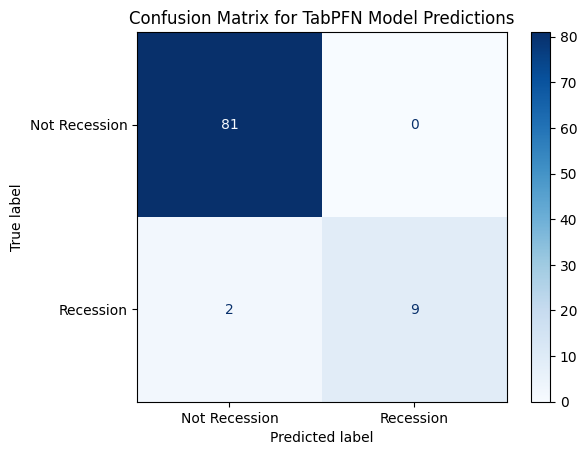

In [23]:
# Create confusion matrix
confusion_matrix_original = confusion_matrix(target_test_original, predictions_original)

# Display confuusion matrix
display_confusion_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_original, 
    display_labels=tabpfn_model_original.classes_
)
display_confusion_matrix.plot(cmap='Blues')

# Create title for the confusion matrix and display it
plt.title("Confusion Matrix for TabPFN Model Predictions")
plt.show()

From the confusion matrix, we can see that the model perfectly classified all Not Recession entries. However, it misclassified 2 **Recession** entries as **Not Recession**. While 2 may seem like a small number, there are only 11 **Recession** entries in the test set. This means the model misclassified about **18% of the recession cases**, which is a significant error and is reflected in the lower recall and F1-score for the **Recession** class shown in the evaluation metrics above.

### 3.6 Create Feature List and Target for Evaluation

Similarly to the fine-tuning section, we select the same macroeconomic indicators as features for the evaluation dataset.

These features will be used to make predictions for the economic_state.

In [24]:
# List of features that are going to be for TabPFN fine-nuning
features_evaluation_original = df_evaluation_original[[
    "cpi",
    "mortgage_rate",
    "unemp_rate",
    "nasdaq",
    "disposable_income",
    "personal_consumption_expenditure",
    "personal_savings"
]]

The trained TabPFN model is used to predict the economic_state for the evaluation data.

In [25]:
# Create predictions for the original evaluation dataset that does not have economic_state values.
df_evaluation_original['economic_state'] = tabpfn_model_original.predict(features_evaluation_original.values)

/home/user/anaconda3/envs/GRU/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_134686/1593740769.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evaluation_original['economic_state'] = tabpfn_model_original.predict(features_evaluation_original.values)


Next we compare the predicted results with the original labels in the evaluation dataset to see the distribution of economic states.

In [26]:
# Create pandas table using df_evaluation_with_saved_labels and df_evaluation_original datasets
comparison_table = pd.DataFrame({
    "Original": df_evaluation_with_saved_labels["economic_state"].value_counts(),
    "Predicted": df_evaluation_original["economic_state"].value_counts()
})

# Display the table
comparison_table

,Original,Predicted
economic_state,,
Not Recession,38,41.0
Recession,3,NaN


From the comparison table, we can see that the original evaluation dataset had 3 **Recession** entries, but the TabPFN model classified all entries as **Not Recession**.

This is likely due to two main reasons:

1.	**Class imbalance** – The original dataset was heavily imbalanced, with 442 **Not Recession** entries and only 57 Recession entries. The model had much more data to learn Not Recession periods, making it harder to recognize Recession periods.
  
2. **COVID-19 recession characteristics** – The 2020 recession was very short, lasting only a few months. Government interventions also made it unusual compared to past recessions, making it harder for the model to detect.


The next step is to apply **SMOTE** to generate synthetic **Recession** entries and check if it improves the model’s performance.

---

# 4. TabPFN Model Tuning and Evaluation using SMOTE data

### 4.1 Handle Class Imbalance Using SMOTE

First step is to resample the dataset using SMOTE to balance the classes.

Synthetic entries are generated for the minority class, and the resampled dataset is created with features, target, and original dates preserved.

In [27]:
# Copy dates so we can injected them later after we apply SMOTE
dates = df["date"].copy()

# List of features we want SMOTE to generate
features = [
    "cpi",	
    "mortgage_rate",
    "unemp_rate",
    "nasdaq",
    "disposable_income",
    "personal_consumption_expenditure",
    "personal_savings"
]

# How much SMOTE should increase the minority class
smote_sampling_str = 0.4

# Set the number of nearest neighbours used by SMOTE
smore_k_n = 1

# Create SMOTE
smote = SMOTE(sampling_strategy = smote_sampling_str, k_neighbors = smore_k_n, random_state = 42)

# Create synthetic samples for the minority class(Recession
X_res, y_res = smote.fit_resample(df[features], df["economic_state"])

# Create a DataFrame from the resampled data
df_resampled = pd.DataFrame(X_res, columns = features)

# Add labels to the resampled economic state 
df_resampled["economic_state"] = y_res

# Add the dates column to the resampled dataset
df_resampled["date"] = dates

df_resampled.head()

,cpi,mortgage_rate,unemp_rate,nasdaq,disposable_income,personal_consumption_expenditure,personal_savings,economic_state,date
0,85.6,14.2050,7.5,200.685556,4976.5,1826.8,11.6,Not Recession,1980-11-01
1,86.4,14.7900,7.2,198.398636,4999.8,1851.7,11.4,Not Recession,1980-12-01
2,87.2,14.9040,7.5,198.817619,4980.4,1870.0,10.9,Not Recession,1981-01-01
3,88.0,15.1325,7.4,194.852105,4965.0,1884.2,10.8,Not Recession,1981-02-01
4,88.6,15.4000,7.4,203.593182,4979.0,1902.9,10.8,Not Recession,1981-03-01


In [28]:
# Check the balance of the new dataset
print(df_resampled['economic_state'].value_counts())

economic_state
Not Recession    442
Recession        176
Name: count, dtype: int64


After applying SMOTE, the dataset is more balanced, with 442 **Not Recession** entries and 176 **Recession** entries.

This should help the model learn **Recession** periods more effectively.

The next step is to create the fine-tuning and evaluation datasets using the resampled data.

### 4.2 Create Fine-Tuning and Evaluation Datasets from the Resampled Data

Similar as before, we split the resampled dataset into fine-tuning and evaluation sets based on dates.
•	The fine-tuning set contains data **before** the evaluation period.
•	The evaluation set contains data **within** the evaluation period.
•	The **economic_state** column in the evaluation set is cleared to prepare it for predictions, while features and target are selected from the resampled, balanced dataset.


In [29]:
# Date from where the evaluation dataset should start
df_evaluation_start_date = pd.Timestamp("2018-12-31")
# Date where the evaluation dataset should end
df_evaluation_end_date = pd.Timestamp("2022-05-01")

# Create fine-tuning dataset from the beginning of the SMOTE dataset up until the beginning of the evaluation dataset
df_fine_tuning_smote = df_resampled[~df_resampled["date"].between(df_evaluation_start_date, df_evaluation_end_date)]

# Create an evaluation Dataset that is going to be used to create predictions
df_evaluation_smote = df_resampled[df_resampled["date"].between(df_evaluation_start_date, df_evaluation_end_date)]

# Remove values from economic_state column.
df_evaluation_smote["economic_state"] = ""

/tmp/ipykernel_134686/236799439.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evaluation_smote["economic_state"] = ""


### 4.3 Create feature list for TabPFN fine tuning

Next, we select the relevant macroeconomic indicators from the resampled dataset as **features** and the **economic_state** as the **target** for fine-tuning the TabPFN model.

This prepares the data for training and evaluation on the balanced dataset.

In [30]:
# List of features that are going to be for TabPFN fine-nuning
features_smote = df_fine_tuning_smote[[
    "cpi",
    "mortgage_rate",
    "unemp_rate",
    "nasdaq",
    "disposable_income",
    "personal_consumption_expenditure",
    "personal_savings"
]]

# Target for TabPFN fine-tuning
target_smote = df_fine_tuning_smote["economic_state"]

In [31]:
# Split features and target using 80/20 ratio  
features_train_smote, features_test_smote, target_train_smote, target_test_smote = train_test_split(
    features_smote, 
    target_smote, 
    test_size=0.2, 
    random_state = 42, 
    stratify = target_smote
)

### 4.4 Create TabPFN model, fine-tune and create predictions

Then, we create a TabPFN model and fine-tune it using the training data from the resampled dataset.

The model is then used to make predictions on the test set to evaluate its performance on the balanced data.

In [32]:
# Create TabPFN model using device(CUDA/CPU)
tabpfn_model_smote = TabPFNClassifier(device = device)

# Fine-tune TabPFN
tabpfn_model_smote.fit(features_train_smote, target_train_smote)

# Create predictions 
predictions_smote = tabpfn_model_smote.predict(features_test_smote)

### 4.5 Create evaluation metrics and confusion matrix

Now, we evaluate the TabPFN model trained on the resampled dataset using standard metrics and a confusion matrix.
- **Precision** measures how many of the predicted positives are actually correct.
- **Recall** measures how many of the actual positives were correctly identified.
- **F1-score** is the harmonic mean of precision and recall, balancing the two.
- **Accuracy** is the overall proportion of correct predictions.

A **confusion matrix** is also displayed to show the number of correct and incorrect classifications for each class, helping us see how well the model performs on the balanced dataset.


In [33]:
print(classification_report(target_test_smote, predictions_smote))

               precision    recall  f1-score   support

Not Recession       0.99      0.99      0.99        81
    Recession       0.97      0.97      0.97        35

     accuracy                           0.98       116
    macro avg       0.98      0.98      0.98       116
 weighted avg       0.98      0.98      0.98       116



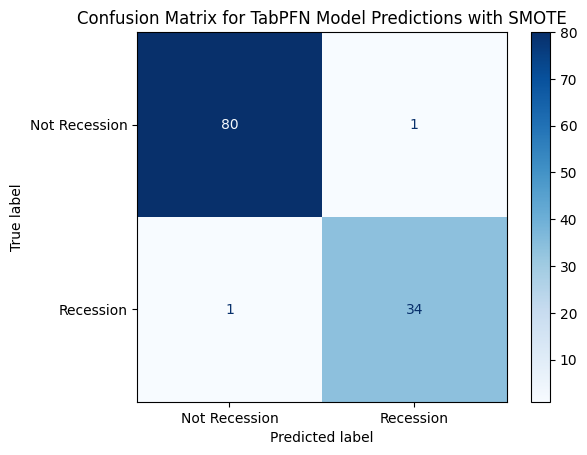

In [34]:
# Create confusion matrix
confusion_matrix_smote = confusion_matrix(target_test_smote, predictions_smote)

# Display confuusion matrix
display_confusion_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_smote, 
    display_labels=tabpfn_model_original.classes_
)

display_confusion_matrix.plot(cmap='Blues')

# Create title for the confusion matrix and display it
plt.title("Confusion Matrix for TabPFN Model Predictions with SMOTE")
plt.show()

### 4.6 Create Feature List and Target for Evaluation with SMOTE

Finally, we select the same macroeconomic indicators as features for the evaluation dataset, but now using the resampled (SMOTE) dataset.

The trained TabPFN model is then used to predict the economic_state for the evaluation data.

In [35]:
# List of features that are going to be for TabPFN fine-tuning
features_evaluation = df_evaluation_smote[[
    "cpi",
    "mortgage_rate",
    "unemp_rate",
    "nasdaq",
    "disposable_income",
    "personal_consumption_expenditure",
    "personal_savings"
]]

features_evaluation.head()

,cpi,mortgage_rate,unemp_rate,nasdaq,disposable_income,personal_consumption_expenditure,personal_savings
458,252.470,4.4640,4.0,6979.654952,14714.3,14104.4,8.7
459,253.135,4.3700,3.8,7430.077263,14742.1,14117.9,8.8
460,254.273,4.2650,3.8,7629.366048,14732.5,14244.4,8.2
461,255.163,4.1425,3.6,7995.064364,14678.0,14329.3,7.7
462,255.325,4.0720,3.6,7804.820818,14673.5,14372.2,7.4


Now lets explore the pruduced result for the evaluation dataset.

In [36]:
# Create predictions for the original evaluation dataset that does not have economic_state values.
df_evaluation_smote['economic_state'] = tabpfn_model_smote.predict(features_evaluation.values)

print(df_evaluation_smote[["date", "economic_state"]].head(60))

/home/user/anaconda3/envs/GRU/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(


          date economic_state
458 2019-01-01  Not Recession
459 2019-02-01  Not Recession
460 2019-03-01  Not Recession
461 2019-04-01  Not Recession
462 2019-05-01  Not Recession
463 2019-06-01  Not Recession
464 2019-07-01  Not Recession
465 2019-08-01  Not Recession
466 2019-09-01  Not Recession
467 2019-10-01  Not Recession
468 2019-11-01  Not Recession
469 2019-12-01  Not Recession
470 2020-01-01  Not Recession
471 2020-02-01  Not Recession
472 2020-03-01  Not Recession
473 2020-04-01      Recession
474 2020-05-01      Recession
475 2020-06-01      Recession
476 2020-07-01      Recession
477 2020-08-01      Recession
478 2020-09-01  Not Recession
479 2020-10-01  Not Recession
480 2020-11-01  Not Recession
481 2020-12-01  Not Recession
482 2021-01-01      Recession
483 2021-02-01  Not Recession
484 2021-03-01      Recession
485 2021-04-01  Not Recession
486 2021-05-01  Not Recession
487 2021-06-01  Not Recession
488 2021-07-01  Not Recession
489 2021-08-01  Not Recession
490 2021-0

/tmp/ipykernel_134686/412629047.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evaluation_smote['economic_state'] = tabpfn_model_smote.predict(features_evaluation.values)


We can see that using SMOTE-generated synthetic data helped the TabPFN model identify **Recession** periods more effectively. However, the model also classified some periods as **Recession** that were not officially part of a recession.

Officially, the US economy was in **Recession** between **2020-02** and **2020-04**. The model additionally labeled periods such as **2020-05 to 2020-08**, **2021-01**, and **2021-03** as recession periods.

This behaviour is most likely caused by the highly unstable economic conditions during and after the COVID-19 pandemic. SMOTE generated synthetic recession samples that are similar to the macroeconomic indicators observed during these months, which may have influenced the model’s predictions.
This suggests that, with the current approach, the model is limited in identifying **Recession** periods that do not closely match historical recession patterns.

Next, we compare the **original labels**, the **predictions without SMOTE**, and the **predictions with SMOTE** for both **Recession** and **Not Recession** classes.

In [37]:
# Create pandas table using df_evaluation_with_saved_labels and df_evaluation_original datasets
comparison_table = pd.DataFrame({
    "Original": df_evaluation_with_saved_labels["economic_state"].value_counts(),
    "Predicted": df_evaluation_original["economic_state"].value_counts(),
    "Smote Predicted": df_evaluation_smote["economic_state"].value_counts()
})

# Display the table
comparison_table

,Original,Predicted,Smote Predicted
economic_state,,,
Not Recession,38,41.0,34
Recession,3,NaN,7


Officially, the US economy was in a **Recession** for only **three months**, and the TabPFN model trained on the original dataset failed to correctly identify this period, classifying all months as **Not Recession**.

After applying SMOTE, the TabPFN model identified **seven months** as **Recession**. However, as discussed earlier, most of these months fall outside the officially defined recession period. This suggests that the current approach to classifying **Recession** and **Not Recession** states is limited and that additional data or features may be required to improve recession detection.

Despite these limitations, both the **official recession labels** and the **model-based predictions** are retained for further analysis. The official labels are used as a baseline, while the SMOTE-based predictions provide an alternative recession signal.

Given the highly **chaotic economic conditions** during this period, these alternative predictions are still informative and will be used to examine how different recession signals affect the performance of the GRU model for stock market price prediction.

---

# 5. Create SMOTE and Official Recession Datasets

The final step of this notebook is to save the acquired data into two datasets:

- US Macroeconomics with Official Recession Periods
- US Macroeconomics with Smote Predictions


In [38]:
# Save 'US Macroeconomics with Official Recession Periods'
df.to_csv("./Outputs/us_macroeconomics_with_official_reccession_periods.csv", index = False)

In [39]:
# Create a copy of the original DataFrame
df_with_smote_predictions = df.copy()

# Create a map date to economic_state using the SMOTE dataset
smote_map = df_evaluation_smote.set_index("date")["economic_state"]

# Replace economic_state values in the 'df_with_smote_predictions' with SMOTE results
df_with_smote_predictions["economic_state"] = (
    df_with_smote_predictions["date"]
        .map(smote_map)
        .fillna(df_with_smote_predictions["economic_state"])
)

# Save 'US Macroeconomics with Smote Predictions'
df_with_smote_predictions.to_csv("./Outputs/us_macroeconomics_with_smote_predictions.csv", index=False)